# Inspecting Very Large Array - ACS Nearby Galaxy Survey Treasury (VLA-ANGST) Spectral Cube Data

This notebook documents inspection of VLA-ANGST radio observations concerning NGC 3741 - an irregular dwarf galaxy located about 10 million light-years in the constellation Ursa Major. NGC 3741 is notable for its exceptionally extended disk of neutral atomic hydrogen (H I), which reaches much beyond its visible stellar presence when seen in optical images. Its rotation also indicates that the galaxy is strongly dominated by dark matter!

In this notebook, I inspect the structure of the H I spectral cube to see how neutral hydrogen emission changes through radial-velocity channels.

![NGC 3741 imaged by the HST](ngc3741.png)

In [1]:
%pip install astropy spectral_cube matplotlib numpy
from spectral_cube import SpectralCube

cube = SpectralCube.read(
    "radio_data/VLA-ANGST_HI_NGC3741-nat-cube.fits.gz"
)

print(cube)
print("cube shape:", cube.shape)
print("spectral axis:", cube.spectral_axis)


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
SpectralCube with shape=(115, 1024, 1024) and unit=Jy / beam:
 n_x:   1024  type_x: RA---SIN  unit_x: deg    range:   173.721486 deg:  174.329586 deg
 n_y:   1024  type_y: DEC--SIN  unit_y: deg    range:    45.069878 deg:   45.496127 deg
 n_s:    115  type_s: VOPT-F2W  unit_s: m / s  range:   154187.126 m / s:  301268.539 m / s
cube shape: (115, 1024, 1024)
spectral axis: [154187.12639818 155476.68743172 156766.25955374 158055.84276436
 159345.43706371 160635.04245205 161924.65892935 163214.28649588
 164503.92515172 165793.574897   167083.23573198 168372.90765662
 169662.59067125 170952.28477586 172241.98997065 173531.70625586
 174821.43363144 176111.17209772 177400.92165468 178690.68230258
 179980.45404156 181270.23687167 182560.03079318 183849.83580608
 185139.65191063 186429.47910698 187719.31739519 189009

Downloaded natural-weighted versions from the official VLA-ANGST H I data release of:
- NGC 3741 H I data cube
- Moment 0 - total H I
- Moment 1 - average velocity
- Moment 2 - velocity dispersion

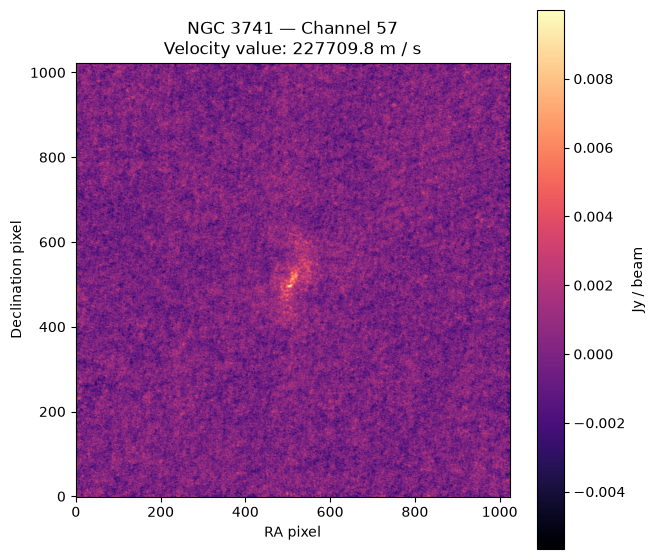

In [2]:
import matplotlib.pyplot as plt

channel_number = cube.shape[0] // 2
channel = cube[channel_number]

plt.figure(figsize=(7, 7))
plt.imshow(channel.value, origin="lower", cmap="magma")
plt.colorbar(label=str(channel.unit))
plt.title(
    f"NGC 3741 — Channel {channel_number}\n"
    f"Velocity value: {cube.spectral_axis[channel_number]:.1f}"
)
plt.xlabel("RA pixel")
plt.ylabel("Declination pixel")
plt.show()

I have defined cube with the shape of: `cube[velocity channel, vertical px, horizontal px]`, specifically with specs `cube.shape = (115, 1024, 1024)`, meaning that the cube contains 115 separate "2D" images that each measure H I emission at a different radial velocity.

In the above code I selected the middle channel:
`channel_number = cube.shape[0] // 2`

...which selects the value of 115, then performs integer division by 2 = 57. 
Then, I extracted the 2D image from that channel:
`channel = cube[channel_number]`
or 
`channel = cube[57]`

After creating a figure (or an empty area for plotting), display the channel:
```
plt.imshow(
    channel.value,   #retrieve values
    origin="lower",  #sets origin to lower-left
    cmap="magma"     #choose color map
)
```

Then, created a color bar, added title + labeled the axes, and finally displayed the plot!

### Create more plots to explore the data further!

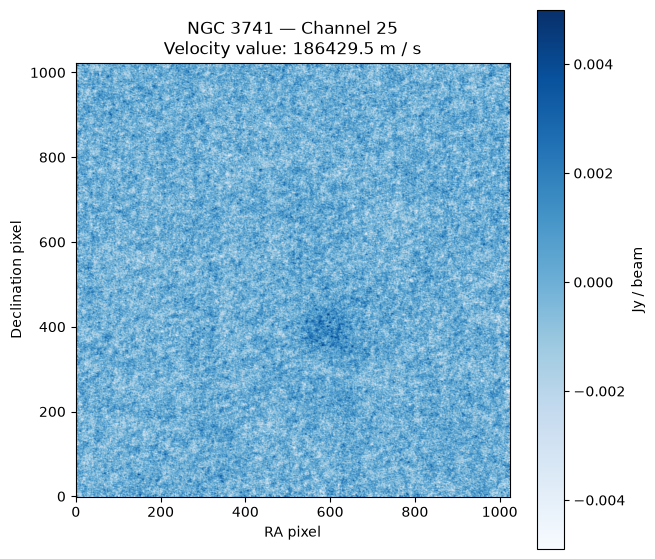

In [3]:
channel_number = 25
channel = cube[channel_number]

plt.figure(figsize=(7, 7))
plt.imshow(channel.value, origin="lower", cmap="Blues")
plt.colorbar(label=str(channel.unit))
plt.title(
    f"NGC 3741 — Channel {channel_number}\n"
    f"Velocity value: {cube.spectral_axis[channel_number]:.1f}"
)
plt.xlabel("RA pixel")
plt.ylabel("Declination pixel")
plt.show()

> Color maps are so fun!!!

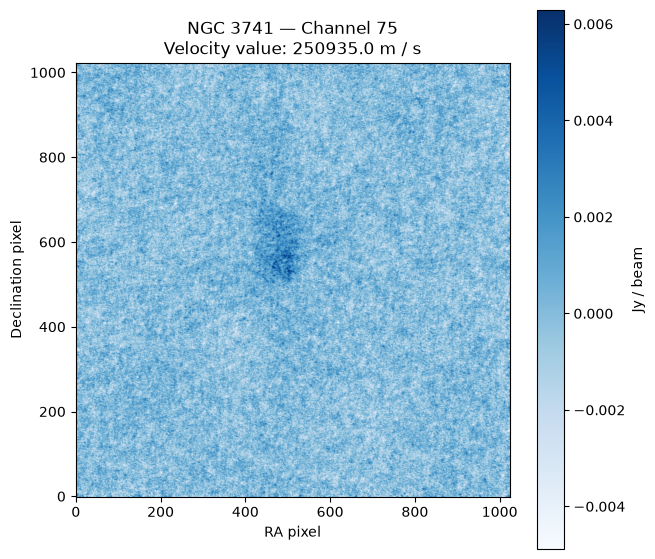

In [4]:
channel_number = 75
channel = cube[channel_number]

plt.figure(figsize=(7, 7))
plt.imshow(channel.value, origin="lower", cmap="Blues")
plt.colorbar(label=str(channel.unit))
plt.title(
    f"NGC 3741 — Channel {channel_number}\n"
    f"Velocity value: {cube.spectral_axis[channel_number]:.1f}"
)
plt.xlabel("RA pixel")
plt.ylabel("Declination pixel")
plt.show()

### Initial notes
I was able to successfully load the VLA-ANGST data for NGC 3741 as a spectral cube with 115 velocity channels and 1024x1024 spatial pixels. There are notable differences of distribution of H I emission between velocity channels - what would I be able to notice about the structure of this irregular galaxy if examined in 3 dimensions?

This dataset is suitable for construction of PPV (position-position-velocity) visualization!
However, background noise should be removed from visible emission (data-wrangling - is that what it's called?).